In [1]:
!pip install -U segment-geospatial opencv-python-headless rasterio shapely gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.2/142.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 10.8 MB/s eta 0:00:00


In [2]:
!gdown --id 1WZVp4uCbStZvp-4vyomdaan6OK-1VIlp

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WZVp4uCbStZvp-4vyomdaan6OK-1VIlp
From (redirected): https://drive.google.com/uc?id=1WZVp4uCbStZvp-4vyomdaan6OK-1VIlp&confirm=t&uuid=40cc51cc-d013-4c8c-831a-7ab1527a93ef
To: /content/OneraDataset.zip
100% 528M/528M [00:10<00:00, 52.4MB/s]


In [3]:
!unzip -q /content/OneraDataset.zip -d /content/

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:23<00:00, 108MB/s] 


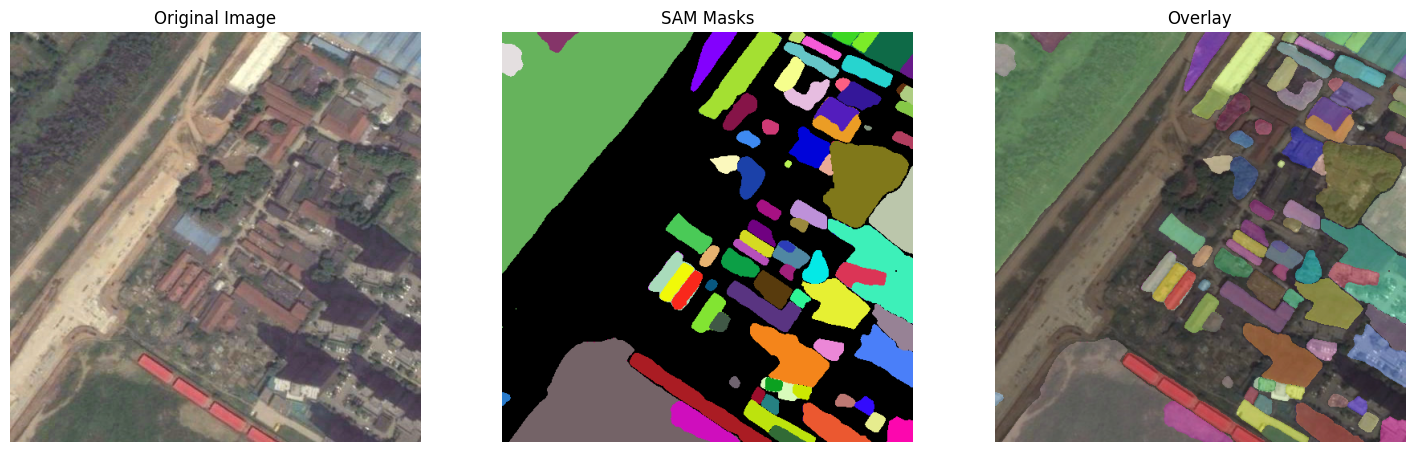

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from samgeo import SamGeo
import os

# Get uploaded image name
image_path = r"/content/00013.png"

# Load SAM (ViT-H)
sam = SamGeo(
    model_type="vit_h",
    automatic=True,
    device="cuda"
)

# Generate masks
sam.generate(image_path)

# Load image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get SAM masks
masks = sam.masks

# Create colored mask
h, w, _ = img.shape
colored_mask = np.zeros((h, w, 3), dtype=np.uint8)

np.random.seed(42)
for m in masks:
    color = np.random.randint(0, 255, size=3)
    colored_mask[m['segmentation'] > 0] = color

# Overlay
overlay = (0.6 * img + 0.4 * colored_mask).astype(np.uint8)

# Show results
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("SAM Masks")
plt.imshow(colored_mask)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

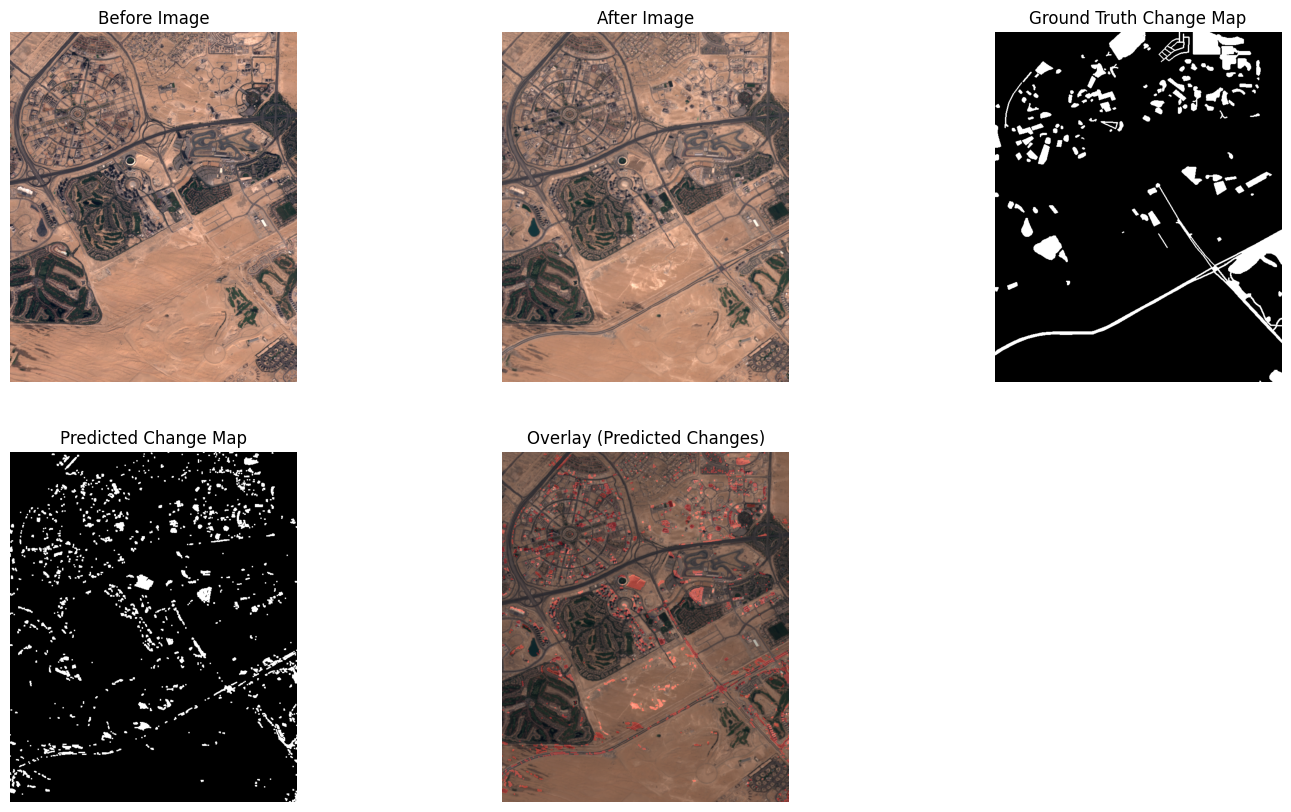

Accuracy: 0.8956056048712494
Precision: 0.4617770150242375
Recall: 0.3149992811518002
F1 Score: 0.37452076872359646


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from samgeo import SamGeo

# ----------------------------
# Load image paths
# ----------------------------
image_names = [r"/content/Onera Dataset/Images/Test/dubai/pair/img1.png", r"/content/Onera Dataset/Images/Test/dubai/pair/img2.png"]
before_path = image_names[0]
after_path  = image_names[1]

# ----------------------------
# Initialize SAM (ViT-H)
# ----------------------------
sam = SamGeo(
    model_type="vit_h",
    automatic=True,
    device="cuda"
)

def sam_to_semantic(image_path):
    sam.generate(image_path)
    masks = sam.masks

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    semantic = np.zeros((h, w), dtype=np.uint8)

    for i, m in enumerate(masks):
        semantic[m['segmentation'] > 0] = i + 1   # region IDs

    return img, semantic

# ----------------------------
# Segment both images
# ----------------------------
img_before, sem_before = sam_to_semantic(before_path)
img_after,  sem_after  = sam_to_semantic(after_path)

# ----------------------------
# Change detection
# ----------------------------
diff = cv2.absdiff(img_before, img_after)
diff_gray = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)

threshold = 25
change_map = (diff_gray > threshold).astype(np.uint8)

# Remove noise
kernel = np.ones((3,3), np.uint8)
change_map = cv2.morphologyEx(change_map, cv2.MORPH_OPEN, kernel)

# ground truth

gt = cv2.imread(r"/content/Onera Dataset/TestLabels/dubai/cm/cm.png", cv2.IMREAD_GRAYSCALE)
gt = (gt > 0).astype(np.uint8)

# ----------------------------
# Visualization
# ----------------------------
change_color = np.zeros((*change_map.shape, 3), dtype=np.uint8)
change_color[change_map == 1] = [255, 0, 0]  # red = change

overlay = (0.7 * img_after + 0.3 * change_color).astype(np.uint8)

plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.title("Before Image")
plt.imshow(img_before)
plt.axis("off")

plt.subplot(2,3,2)
plt.title("After Image")
plt.imshow(img_after)
plt.axis("off")

plt.subplot(2,3,3)
plt.title("Ground Truth Change Map")
plt.imshow(gt, cmap="gray")
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Predicted Change Map")
plt.imshow(change_map, cmap="gray")
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Overlay (Predicted Changes)")
plt.imshow(overlay)
plt.axis("off")

plt.show()


#--------------------
# Acuracy
#--------------------

pred = change_map.astype(np.uint8)
gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)

TP = np.sum((pred == 1) & (gt == 1))
TN = np.sum((pred == 0) & (gt == 0))
FP = np.sum((pred == 1) & (gt == 0))
FN = np.sum((pred == 0) & (gt == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)